# MamaCare: End-to-End Maternal Health Risk Prediction

A reproducible capstone using the UCI Maternal Health Risk dataset. Results are academic screening support only and are not medical diagnoses.

## 1. Project overview

The task is three-class prediction with group-separated evaluation, one-missing-measurement support, uncertainty warnings, and local model-sensitivity explanations.

## 2. Dataset source and citation

Source: [UCI Maternal Health Risk](https://archive.ics.uci.edu/dataset/863/maternal+health+risk). The raw source is preserved unchanged.

## 3. Imports and reproducibility

A fixed seed is used throughout.

In [1]:
from pathlib import Path
import sys, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
SEED=42
np.random.seed(SEED)
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(ROOT)

C:\Users\jmika\OneDrive\Desktop\Mama Care


## 4. Data loading

The validated raw file is loaded from a repository-relative path.

In [2]:
raw=pd.read_csv(ROOT/'data/raw/Maternal Health Risk Data Set.csv')
print(raw.shape)
display(raw.head(), raw.tail())

(1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


## 5. Data-quality checks

Checks cover schema, types, missing values, duplicates, labels, ranges, and summary statistics.

In [3]:
display(raw.dtypes.to_frame('dtype'))
print('Missing:', raw.isna().sum().to_dict())
print('Duplicates:', raw.duplicated().sum())
print('Classes:', raw.RiskLevel.value_counts().to_dict())
display(raw.describe())

,dtype
Age,int64
SystolicBP,int64
DiastolicBP,int64
BS,float64
BodyTemp,float64
HeartRate,int64
RiskLevel,str


Missing: {'Age': 0, 'SystolicBP': 0, 'DiastolicBP': 0, 'BS': 0, 'BodyTemp': 0, 'HeartRate': 0, 'RiskLevel': 0}
Duplicates: 562
Classes: {'low risk': 406, 'mid risk': 336, 'high risk': 272}


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


## 6. Cleaning

Labels are stripped and lower-cased. No rows are removed. The HeartRate minimum of 7 appears implausible but is retained because provenance is insufficient for correction.

In [4]:
clean=pd.read_csv(ROOT/'data/processed/maternal_health_risk_cleaned.csv')
print('Cleaned shape:', clean.shape, 'Effect on rows:', len(clean)-len(raw))

Cleaned shape: (1014, 7) Effect on rows: 0


## 7. Exploratory analysis

Plots describe associations only; they do not establish causation.

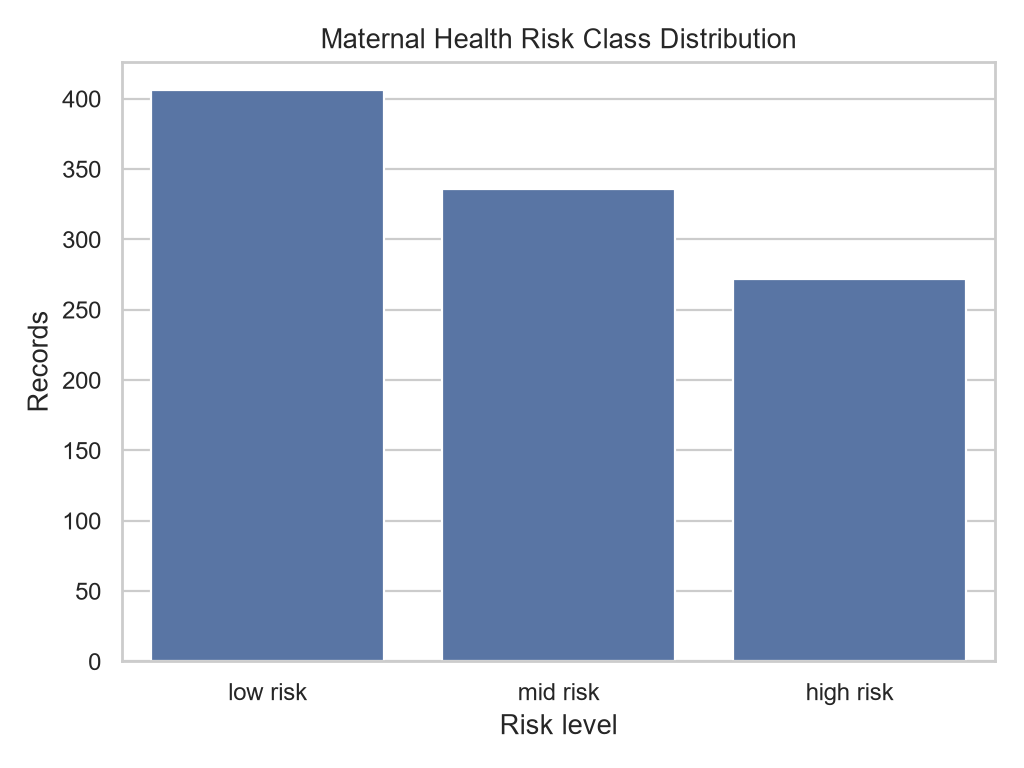

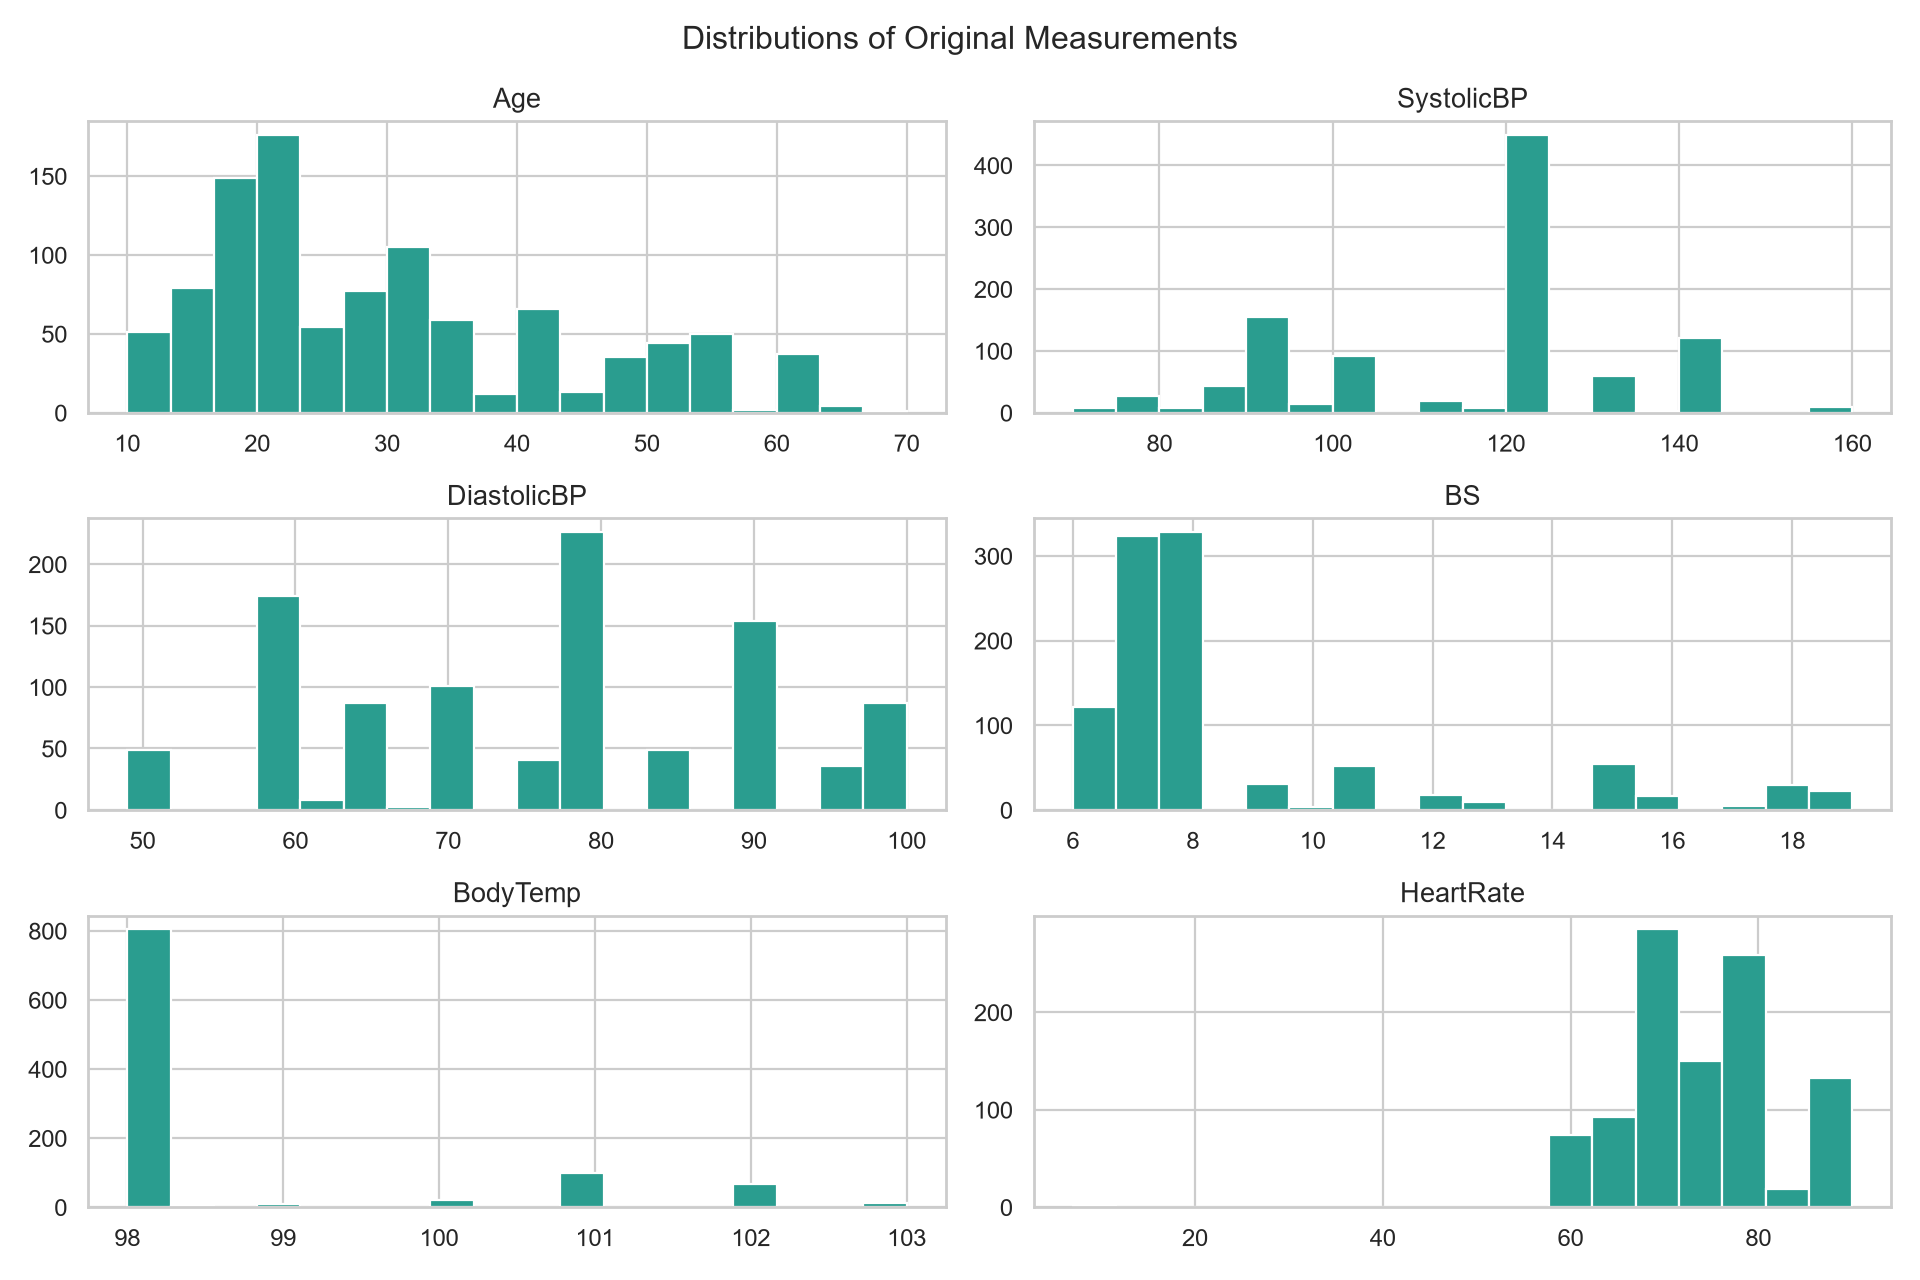

In [5]:
display(Image(filename=str(ROOT/'reports/figures/class_distribution.png')))
display(Image(filename=str(ROOT/'reports/figures/feature_histograms.png')))

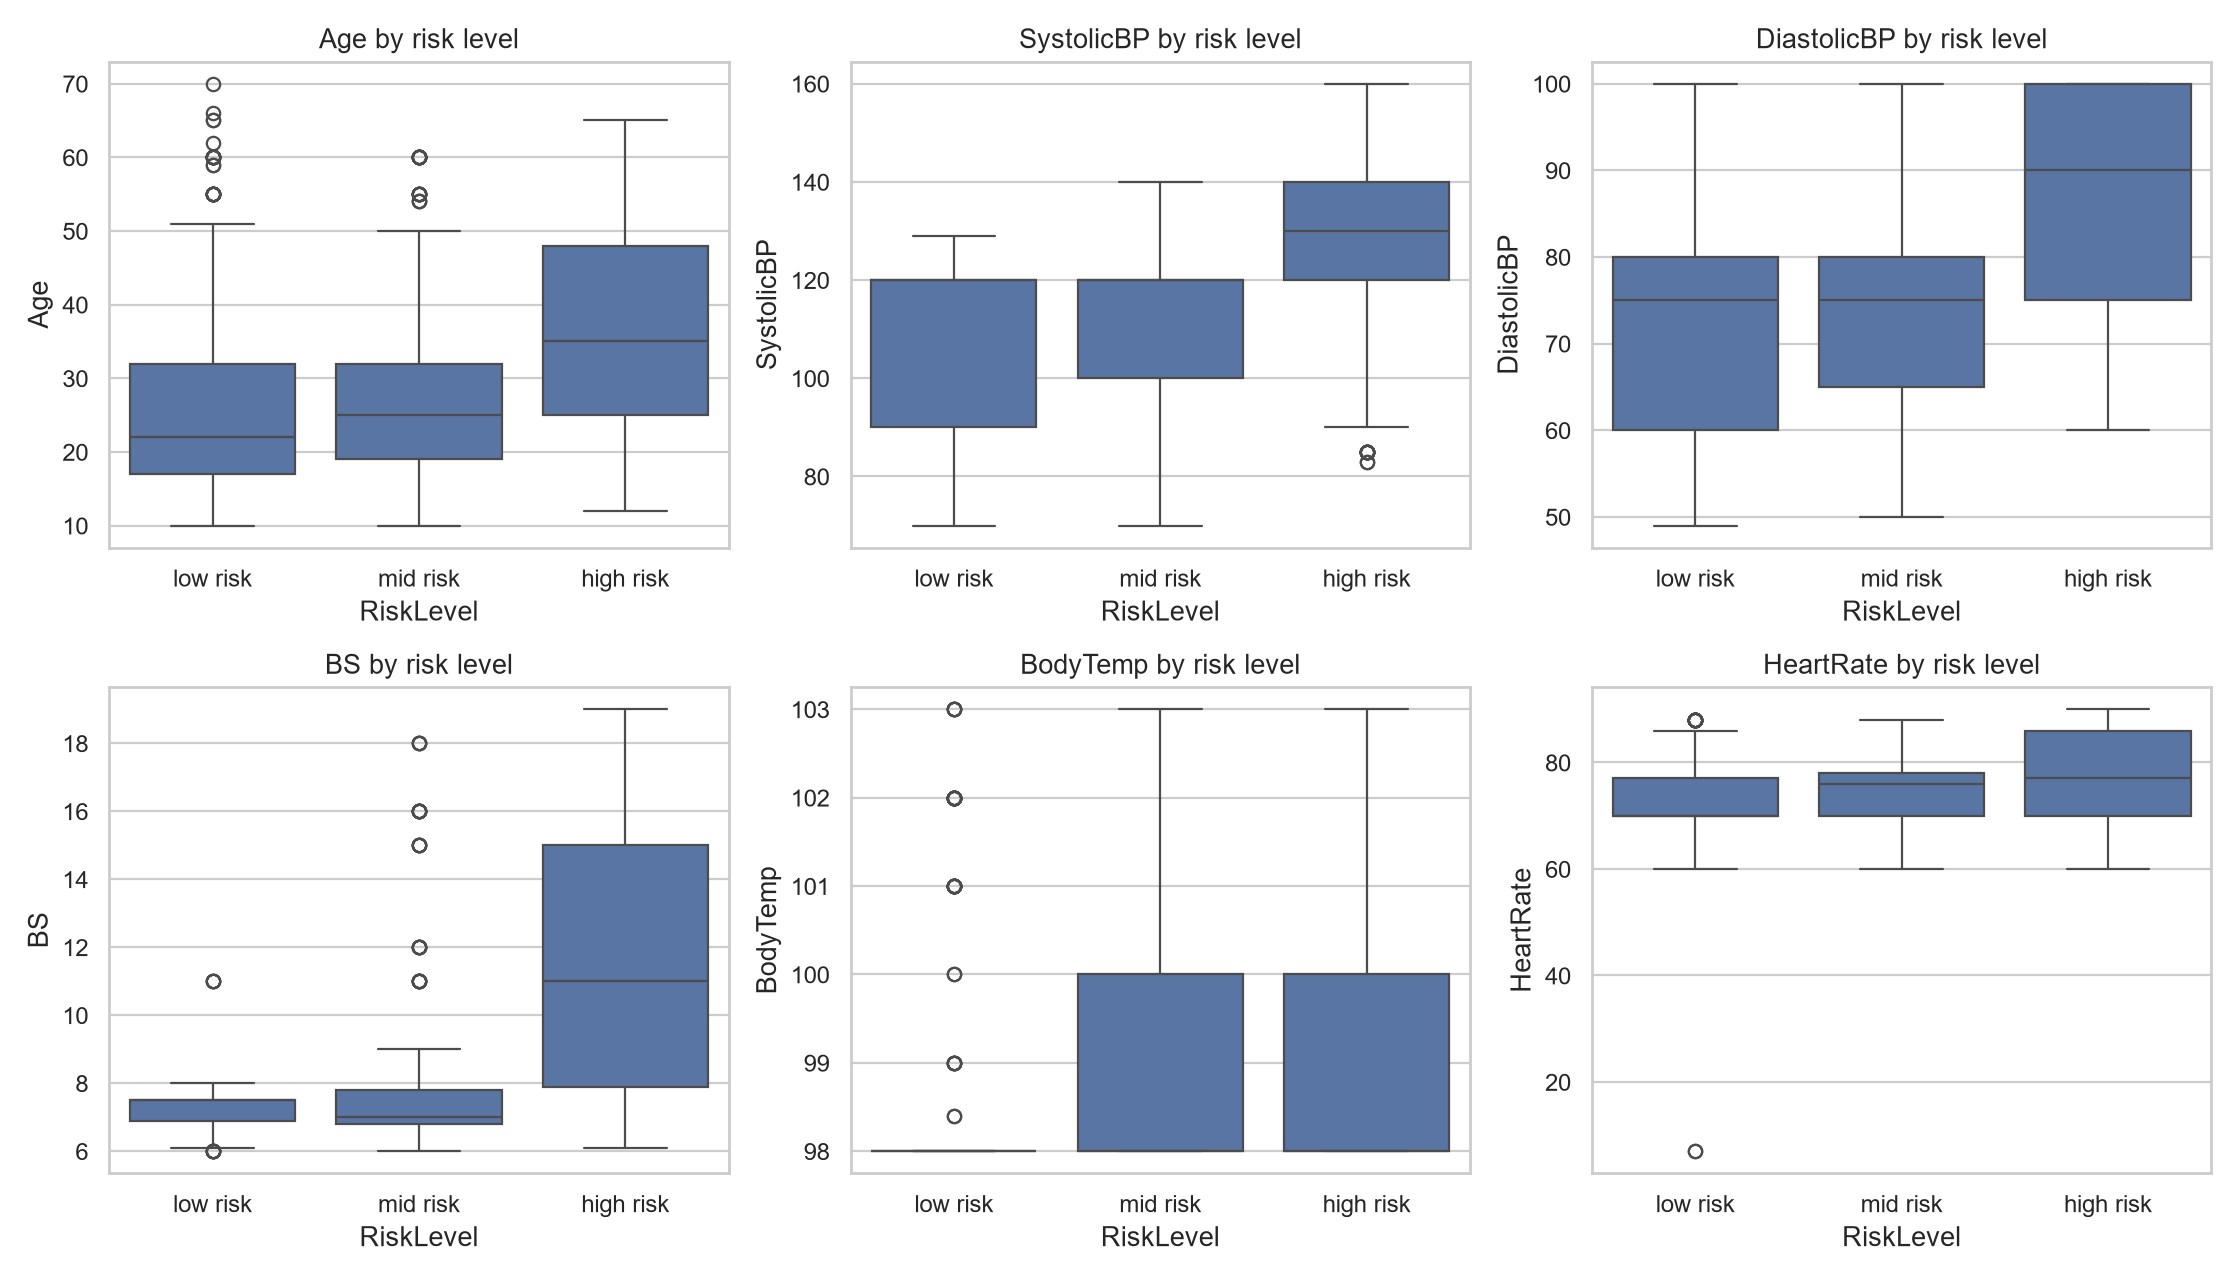

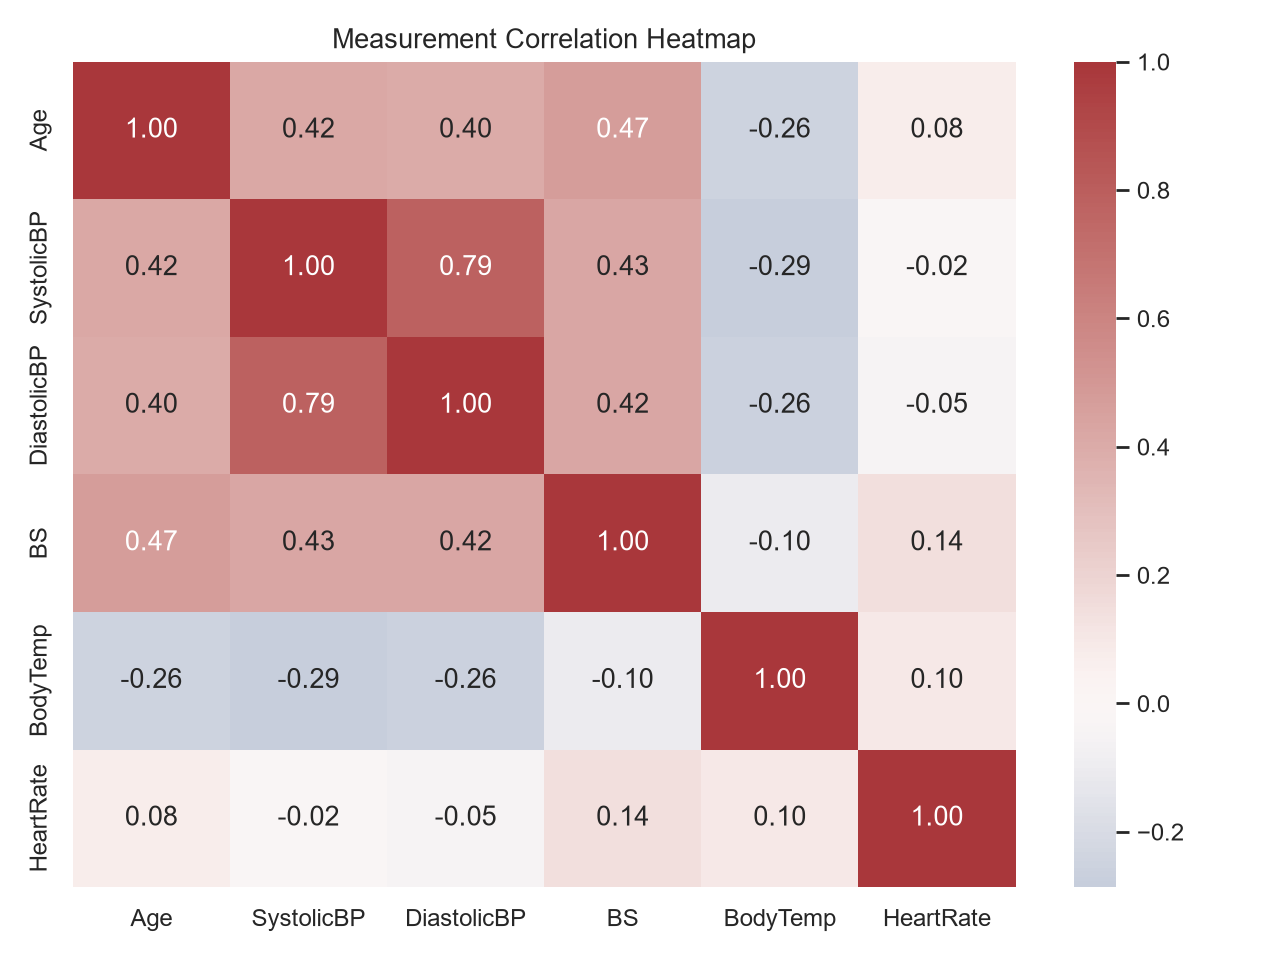

In [6]:
display(Image(filename=str(ROOT/'reports/figures/feature_boxplots_by_risk.png')))
display(Image(filename=str(ROOT/'reports/figures/correlation_heatmap.png')))

## 8. Feature engineering

Pulse pressure, mean arterial pressure, and documented general age bands are computed without target information.

In [7]:
from src.feature_engineering import add_engineered_features
engineered=add_engineered_features(clean.drop(columns='RiskLevel'))
display(engineered.head())

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MeanArterialPressure,AgeBand
0,25,130,80,15.0,98.0,86,50,96.666667,1.0
1,35,140,90,13.0,98.0,70,50,106.666667,2.0
2,29,90,70,8.0,100.0,80,20,76.666667,1.0
3,30,140,85,7.0,98.0,70,55,103.333333,1.0
4,35,120,60,6.1,98.0,76,60,80.000000,2.0


## 9. Clustering

K-Means, silhouette comparison, hierarchical clustering, and PCA are exploratory profiles—not diagnoses or replacements for RiskLevel.

,clusters,inertia,silhouette
0,2,4381.474010,0.297124
1,3,3354.828577,0.292692
2,4,2739.141818,0.306339
3,5,2419.234551,0.303494
4,6,2209.938862,0.291438


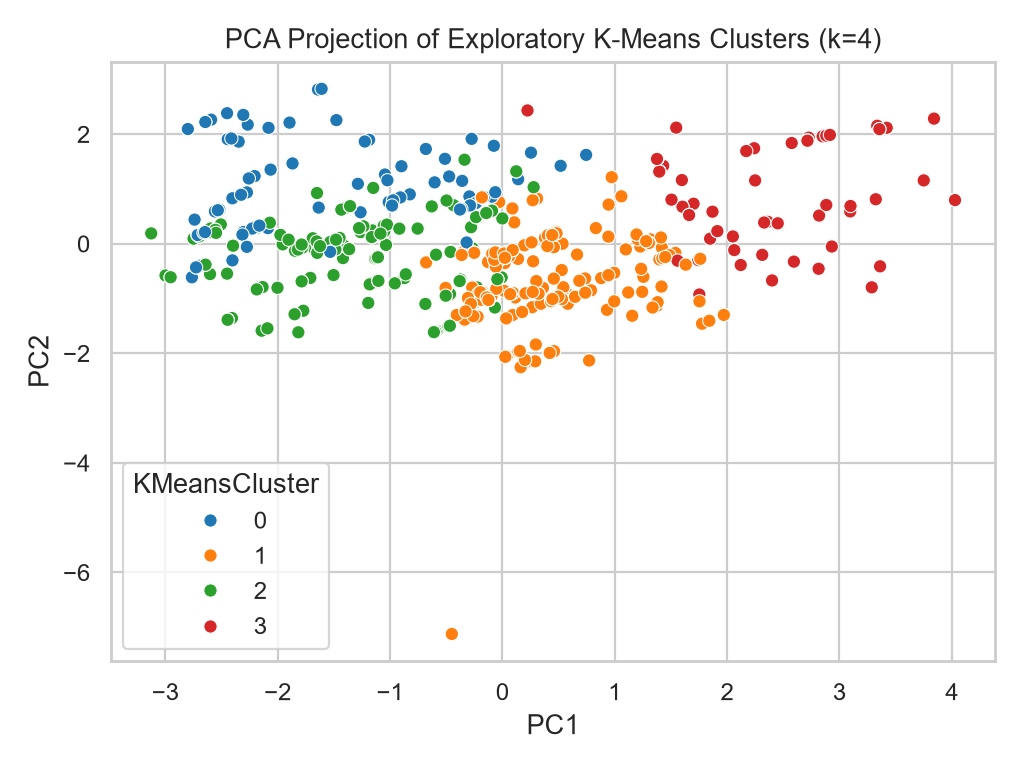

In [8]:
display(pd.read_csv(ROOT/'reports/tables/clustering_metrics.csv'))
display(Image(filename=str(ROOT/'reports/figures/cluster_pca.png')))

## 10. Data splitting

StratifiedGroupKFold groups the six-measurement signature. This prevents identical inputs crossing train, validation, and test sets.

In [9]:
display(pd.read_csv(ROOT/'reports/tables/split_distribution.csv'))

,split,class,count
0,train,low risk,243
1,train,mid risk,202
2,train,high risk,163
3,validation,low risk,82
4,validation,mid risk,67
5,validation,high risk,54
6,test,low risk,81
7,test,mid risk,67
8,test,high risk,55


## 11. Baseline models

DummyClassifier provides a prior-frequency baseline.

## 12. Traditional models

Logistic regression, decision tree, random forest, SVC, and gradient boosting are compared.

## 13. Neural-network models

Shallow and deeper MLPClassifier models are used because TensorFlow is not reliable for the authorized Python 3.14 environment.

## 14. Ensemble experiment

A soft-voting logistic/random-forest/SVC ensemble is retained only as a comparison candidate.

## 15. Hyperparameter choices

Search scope is computationally modest: regularized SVC, bounded trees, 250–350 forest trees, and early-stopped MLPs.

## 16. Model comparison

Selection prioritizes validation Macro F1, then High Risk recall and probability quality—not accuracy alone.

In [10]:
results=pd.read_csv(ROOT/'reports/model_results.csv')
display(results)

,model,cv_macro_f1_mean,cv_macro_f1_std,cv_accuracy_mean,validation_accuracy,validation_macro_f1,validation_macro_precision,validation_macro_recall,validation_high_risk_recall,validation_log_loss
0,SVC,0.629769,0.047307,0.644784,0.758621,0.758423,0.756265,0.761821,0.833333,0.671475
1,SoftVoting,0.639674,0.060788,0.654677,0.738916,0.741218,0.742164,0.741345,0.796296,0.644474
2,LogisticRegression,0.561905,0.051768,0.565844,0.684729,0.691336,0.698073,0.690882,0.777778,0.739782
3,RandomForest,0.636611,0.053646,0.659660,0.669951,0.668774,0.666432,0.673848,0.759259,0.702349
4,DeepMLP,0.562114,0.129046,0.598790,0.660099,0.647028,0.647019,0.647323,0.629630,0.813419
5,ShallowMLP,0.279976,0.016026,0.368393,0.625616,0.640366,0.704936,0.619825,0.574074,0.913967
6,GradientBoosting,0.650274,0.067809,0.667894,0.665025,0.639695,0.654061,0.654024,0.740741,0.650709
7,DecisionTree,0.628092,0.043955,0.641540,0.635468,0.632584,0.633320,0.644771,0.777778,7.140694
8,Dummy,0.190365,0.000317,0.399673,0.403941,0.191813,0.134647,0.333333,0.000000,1.084325


## 17. Missing-measurement experiment

Reproducible training copies have at most one masked feature. Complete raw records remain unchanged. Median, KNN, and native missing handling are compared.

In [11]:
display(pd.read_csv(ROOT/'reports/tables/imputation_comparison.csv'))
display(pd.read_csv(ROOT/'reports/tables/missing_measurement_results.csv'))

,approach,accuracy,macro_f1,macro_precision,macro_recall,high_risk_recall
0,median,0.605911,0.598793,0.600017,0.604046,0.722222
1,knn,0.635468,0.621723,0.624119,0.629346,0.722222
2,native_hist_gradient,0.620690,0.598193,0.626818,0.607475,0.685185


,missing_feature,accuracy,macro_f1,macro_precision,macro_recall,high_risk_recall,log_loss
0,none,0.522167,0.519897,0.541107,0.522628,0.727273,0.903677
1,Age,0.586207,0.557094,0.579029,0.581962,0.781818,0.885887
2,SystolicBP,0.487685,0.490389,0.538321,0.482149,0.618182,1.032852
3,DiastolicBP,0.507389,0.483590,0.517584,0.494945,0.600000,0.919519
4,BS,0.482759,0.473311,0.500802,0.476314,0.618182,1.049558
5,BodyTemp,0.551724,0.507452,0.528045,0.544331,0.763636,0.870137
6,HeartRate,0.541872,0.522076,0.534299,0.539315,0.745455,0.919703


## 18. Probability calibration

Sigmoid calibration was tested and rejected because validation log loss worsened.

In [12]:
meta=json.loads((ROOT/'models/model_metadata.json').read_text())
print('Uncalibrated:', meta['validation_log_loss_uncalibrated'])
print('Calibrated:', meta['validation_log_loss_calibrated'])
print('Retained calibration:', meta['calibrated'])

Uncalibrated: 0.7180490837022729
Calibrated: 0.7292422286566804
Retained calibration: False


## 19. Uncertainty threshold

Validation maximum-probability thresholds compare prediction coverage with error rate. The predicted class remains visible when flagged.

In [13]:
display(pd.read_csv(ROOT/'reports/tables/uncertainty_thresholds.csv'))
print('Selected:', meta['uncertainty_threshold'])

,threshold,coverage,error_rate
0,0.40,1.000000,0.325123
1,0.45,1.000000,0.325123
2,0.50,0.965517,0.311224
3,0.55,0.807882,0.256098
4,0.60,0.778325,0.253165
5,0.65,0.694581,0.205674
6,0.70,0.581281,0.245763
7,0.75,0.448276,0.230769
8,0.80,0.290640,0.237288
9,0.85,0.088670,0.333333


Selected: 0.65


## 20. Explainability

Median-replacement probability sensitivity is transparent and tested. Direction describes model association, not causation.

In [14]:
from app.app_helpers import predict_result
model=joblib.load(ROOT/'models/maternal_risk_pipeline.joblib')
example=dict(meta['feature_medians'])
display(predict_result(model, meta, example))

{'label': 'low risk',
 'probability': 0.737626083781638,
 'probabilities': {'high risk': 0.04311886969282738,
  'low risk': 0.737626083781638,
  'mid risk': 0.2192550465255348},
 'uncertain': False,
 'explanations': [{'feature': 'Age',
   'importance': 0.0,
   'direction': 'supports'},
  {'feature': 'SystolicBP', 'importance': 0.0, 'direction': 'supports'},
  {'feature': 'DiastolicBP', 'importance': 0.0, 'direction': 'supports'}],
 'missing': 0}

## 21. What-if demonstration

One selected measurement is adjusted. This demonstrates model sensitivity, not treatment advice.

In [15]:
from app.app_helpers import what_if
display(what_if(model, meta, example, 'BS', example['BS']+1))

{'label': 'low risk',
 'probability': 0.5249446203282917,
 'probabilities': {'high risk': 0.21124938055978423,
  'low risk': 0.5249446203282917,
  'mid risk': 0.2638059991119236},
 'uncertain': True,
 'explanations': [{'feature': 'BS',
   'importance': 0.21268146345334626,
   'direction': 'opposes'},
  {'feature': 'Age', 'importance': 0.0, 'direction': 'supports'},
  {'feature': 'SystolicBP', 'importance': 0.0, 'direction': 'supports'}],
 'missing': 0}

## 22. Final untouched test evaluation

The test set was not used for model selection.

In [16]:
display(pd.Series(meta['test_metrics']).to_frame('value'))
display(pd.DataFrame(meta['classification_report']).T)
print(meta['error_analysis'])

,value
accuracy,0.522167
macro_f1,0.519897
macro_precision,0.541107
macro_recall,0.522628
high_risk_recall,0.727273
log_loss,0.903677


,precision,recall,f1-score,support
high risk,0.909091,0.727273,0.808081,55.000000
low risk,0.486957,0.691358,0.571429,81.000000
mid risk,0.227273,0.149254,0.180180,67.000000
accuracy,0.522167,0.522167,0.522167,0.522167
macro avg,0.541107,0.522628,0.519897,203.000000
weighted avg,0.515619,0.522167,0.506415,203.000000


{'actual_high_predicted_low': 4, 'actual_high_predicted_mid': 11, 'actual_mid_predicted_low': 55}


## 23. Model export

The complete fitted estimator, metadata, label mapping, feature ranges, medians, threshold, package versions, and explanation configuration are saved in `models/`.

In [17]:
print((ROOT/'models/maternal_risk_pipeline.joblib').stat().st_size, (ROOT/'models/model_metadata.json').stat().st_size)

86590 3000


## 24. Conclusions

SVC led validation Macro F1. Group-separated test Macro F1 is lower, showing that duplicate-safe evaluation materially changes the generalization estimate.

## 25. Limitations

The dataset is small, heavily duplicated, narrow, potentially includes implausible measurements, and lacks external validation and care context.

## 26. Ethical and practical considerations

False reassurance is possible. The app stores no submitted measurements. Independent local clinical validation, governance, fairness review, and monitoring are prerequisites for any real-world consideration.